## 统计分析

通过指定统计分析字段，得到每个特征的p_value，所有的p_value计算都是基于Ttest计算。支持指定不同的分组`group`，例如train、val、test等分组统计。

对于两大类不同的特征

1. 离散特征，统计数量以及占比。
2. 连续特征，统计均值、方差。

In [1]:
import pandas as pd
import numpy as np
from onekey_algo import OnekeyDS as okds
from onekey_algo import get_param_in_cwd
from onekey_algo.custom.utils import print_join_info

task = get_param_in_cwd('task_column') or 'label'
p_value = get_param_in_cwd('p_value') or 0.05
# 修改成自己临床数据的文件。
test_data = pd.read_csv(get_param_in_cwd('clinic_file') or okds.survival)
stats_columns_settings = get_param_in_cwd('stats_columns')
continuous_columns_settings = get_param_in_cwd('continuous_columns')
mapping_columns_settings = get_param_in_cwd('mapping_columns')
test_data = test_data[[c for c in test_data.columns if c != task]]
test_data['ID'] = test_data['ID'].map(lambda x: f"{x}.nii.gz" if not (f"{x}".endswith('.nii.gz') or  f"{x}".endswith('.nii')) else x)
group_info = pd.read_csv('group.csv')
print_join_info(test_data, group_info)
test_data = pd.merge(test_data, group_info, on='ID', how='inner')
test_data

[2024-10-31 14:54:53 - <frozen onekey_algo.custom.utils>:  57]	INFO	ID特征完全匹配！


,ID,age,nipple_discharge,long,short,Inflammatory_indicators,breast_pain,skin_lesions,margin,angular,echogenic_foci,Blood_flow,group,label
0,1.nii.gz,36,0.0,3.3,1.7,0,0,0,1,0,0,1,train,1
1,2.nii.gz,42,0.0,4.8,2.2,0,0,0,1,0,0,1,train,1
2,3.nii.gz,28,0.0,2.7,1.1,0,0,0,1,0,1,2,train,1
3,4.nii.gz,36,0.0,2.9,1.6,0,0,0,1,0,0,1,train,1
4,5.nii.gz,55,0.0,1.5,0.9,0,0,0,3,0,0,2,train,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,234.nii.gz,50,0.0,1.0,0.7,0,0,0,1,0,1,1,train,1
233,235.nii.gz,41,0.0,1.3,0.9,0,0,0,3,0,1,3,test,1
234,236.nii.gz,38,0.0,3.3,0.7,0,0,0,1,0,1,3,train,1
235,237.nii.gz,34,0.0,2.6,1.2,0,0,0,1,1,1,3,train,1


# 特征名称处理

去掉所有特征名称中的特殊字符。

In [2]:
import re

def map_cnames(x):
    x = re.split('[（|(]', x)[0]
    x = x.replace('-', '_').replace(' ', '_').replace('>', '').replace('/', '_')
    return x.strip()

test_data.columns = list(map(map_cnames, test_data.columns))
test_data.columns

Index(['ID', 'age', 'nipple_discharge', 'long', 'short',
       'Inflammatory_indicators', 'breast_pain', 'skin_lesions', 'margin',
       'angular', 'echogenic_foci', 'Blood_flow', 'group', 'label'],
      dtype='object')

# 分析数据

获取待分析的特征列名，如未制定，自动侦测。

In [3]:
stats_columns = stats_columns_settings or list(test_data.columns[1:-2])
test_data = test_data.copy()[['ID'] + stats_columns + ['group', 'label']]
test_data

,ID,age,nipple_discharge,long,short,Inflammatory_indicators,breast_pain,skin_lesions,margin,angular,echogenic_foci,Blood_flow,group,label
0,1.nii.gz,36,0.0,3.3,1.7,0,0,0,1,0,0,1,train,1
1,2.nii.gz,42,0.0,4.8,2.2,0,0,0,1,0,0,1,train,1
2,3.nii.gz,28,0.0,2.7,1.1,0,0,0,1,0,1,2,train,1
3,4.nii.gz,36,0.0,2.9,1.6,0,0,0,1,0,0,1,train,1
4,5.nii.gz,55,0.0,1.5,0.9,0,0,0,3,0,0,2,train,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,234.nii.gz,50,0.0,1.0,0.7,0,0,0,1,0,1,1,train,1
233,235.nii.gz,41,0.0,1.3,0.9,0,0,0,3,0,1,3,test,1
234,236.nii.gz,38,0.0,3.3,0.7,0,0,0,1,0,1,3,train,1
235,237.nii.gz,34,0.0,2.6,1.2,0,0,0,1,1,1,3,train,1


# 特征队列映射

所有需要进行特征映射的队列，range未制定，可以进行自动判断。

In [4]:
mapping_columns = mapping_columns_settings or [c for c in test_data.columns[1:-2] if test_data[c].dtype == object]
mapping_columns

[]

# 数据映射

针对所有非数值形式的数据，可以进行类别映射。

In [5]:
from onekey_algo.custom.utils import map2numerical

data, mapping = map2numerical(test_data, mapping_columns=mapping_columns)
mapping

{}

# 连续特征列

自动识别所有可能的连续特征列。如果列不是整数，或者列的元素超过5个，则呗认定为连续特征。

In [6]:
continuous_columns = []
for c in stats_columns:
    if len(np.unique(test_data[c])) > 5 or not np.int8 <= test_data[c].dtype <= np.int64:
        continuous_columns.append(c)
        
continuous_columns = continuous_columns_settings or continuous_columns
continuous_columns

['age', 'nipple_discharge', 'long', 'short']

# 缺失值填充

In [7]:
import os
from onekey_algo.custom.components.comp1 import fillna
os.makedirs('data', exist_ok=True)
data.to_csv('data/clinical.csv', index=False)
data = fillna(data)
data

,ID,age,nipple_discharge,long,short,Inflammatory_indicators,breast_pain,skin_lesions,margin,angular,echogenic_foci,Blood_flow,group,label
0,1.nii.gz,36,0.0,3.3,1.7,0,0,0,1,0,0,1,train,1
1,2.nii.gz,42,0.0,4.8,2.2,0,0,0,1,0,0,1,train,1
2,3.nii.gz,28,0.0,2.7,1.1,0,0,0,1,0,1,2,train,1
3,4.nii.gz,36,0.0,2.9,1.6,0,0,0,1,0,0,1,train,1
4,5.nii.gz,55,0.0,1.5,0.9,0,0,0,3,0,0,2,train,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,234.nii.gz,50,0.0,1.0,0.7,0,0,0,1,0,1,1,train,1
233,235.nii.gz,41,0.0,1.3,0.9,0,0,0,3,0,1,3,test,1
234,236.nii.gz,38,0.0,3.3,0.7,0,0,0,1,0,1,3,train,1
235,237.nii.gz,34,0.0,2.6,1.2,0,0,0,1,1,1,3,train,1


### 统计分析

支持两种格式数据，分别对应`pretty`参数的`True`和`False`, 当为`True`时，输出的是表格模式，反之则为dict数据。

```python
def clinic_stats(data: DataFrame, stats_columns: Union[str, List[str]], label_column='label',
                 group_column: str = None, continuous_columns: Union[str, List[str]] = None,
                 pretty: bool = True) -> Union[dict, DataFrame]:
    """

    Args:
        data: 数据
        stats_columns: 需要统计的列名
        label_column: 二分类的标签列，默认`label`
        group_column: 分组统计依据，例如区分训练组、测试组、验证组。
        continuous_columns: 那些列是连续变量，连续变量统计均值方差。
        pretty: bool, 是否对结果进行格式美化。

    Returns:
        stats DataFrame or json

    """
```

In [8]:
from onekey_algo.custom.components.stats import clinic_stats

pd.set_option('display.max_rows', None)
stats = clinic_stats(data, 
                     stats_columns= stats_columns,
                     label_column=task, 
                     group_column='group', 
                     continuous_columns= continuous_columns, 
                     pretty=True, verbose=False)
stats.to_csv('stats.csv', index=False, encoding='utf_8_sig')
stats

,feature_name,train-label=ALL,train-label=0,train-label=1,pvalue,test-label=ALL,test-label=0,test-label=1,pvalue
0,age,40.68±6.74,42.10±6.41,38.92±6.76,<0.001,43.31±8.14,45.65±5.97,40.55±9.55,0.003
1,nipple_discharge,0.07±0.26,0.10±0.29,0.05±0.21,0.154,0.02±0.14,0.00±0.00,0.05±0.21,0.296
2,long,2.53±1.26,2.13±1.18,3.03±1.20,<0.001,2.62±1.73,2.60±2.06,2.64±1.29,0.325
3,short,1.40±0.71,1.28±0.65,1.56±0.75,0.004,1.55±0.95,1.62±1.06,1.46±0.82,0.959
0,Inflammatory_indicators,,,,0.676,,,,0.881
1,0,176(93.12),99(94.29),77(91.67),,45(93.75),25(96.15),20(90.91),
2,1,13(6.88),6(5.71),7(8.33),,3(6.25),1(3.85),2(9.09),
3,breast_pain,,,,0.393,,,,0.274
4,0,168(88.89),91(86.67),77(91.67),,42(87.50),21(80.77),21(95.45),
5,1,21(11.11),14(13.33),7(8.33),,6(12.50),5(19.23),1(4.55),


In [9]:
sel_idx = [True if (isinstance(pv[0], str) and pv[0] != '') or (isinstance(pv[0], float) and pv[0] < p_value) else False 
           for pv in np.array(stats['pvalue'])]
sel_data = data[['ID'] + list(stats[sel_idx]['feature_name']) + ['group', 'label']]
sel_data.to_csv('clinic_sel.csv', index=False)
sel_data

,ID,age,long,short,group,label
0,1.nii.gz,36,3.3,1.7,train,1
1,2.nii.gz,42,4.8,2.2,train,1
2,3.nii.gz,28,2.7,1.1,train,1
3,4.nii.gz,36,2.9,1.6,train,1
4,5.nii.gz,55,1.5,0.9,train,1
5,6.nii.gz,42,3.0,3.0,train,1
6,7.nii.gz,33,3.5,1.5,train,1
7,8.nii.gz,33,1.3,0.5,train,1
8,9.nii.gz,30,3.8,2.3,train,1
9,10.nii.gz,72,1.4,0.8,test,1


# 单因素多因素分析

单因素，步进多因素分析
```python
def uni_multi_variable_analysis(data: pd.DataFrame, features: Union[str, List[str]] = None, label_column: str = 'label',
                                need_norm: Union[bool, List[bool]] = False, alpha=0.1,
                                p_value4multi: float = 0.05, save_dir: Union[str] = None, prefix: str = '',
                                **kwargs):
    """
    单因素，步进多因素分析，使用p_value4multi参数指定多因素分析的阈值
    Args:
        data: 数据
        features: 需要分析的特征，默认除了ID和label_column列，其他的特征都进行分析。
        label_column: 目标列
        need_norm: 是否标准化所有分析的数据, 默认为False
        alpha: CI alpha, alpha/2 %；默认为0.1即95% CI
        p_value4multi: 参数指定多因素分析的阈值，默认为0.05
        save_dir: 保存位置
        prefix: 前缀
        **kwargs:

    Returns:

    """
 ```

,Log(OR),lower 95%CI,upper 95%CI,OR,OR lower 95%CI,OR upper 95%CI,p_value
feature_name,,,,,,,
age,-0.007,-0.013,-0.001,0.993,0.987,0.999,0.043
nipple_discharge,-0.927,-1.902,0.048,0.396,0.149,1.049,0.118
long,0.040,-0.045,0.125,1.041,0.956,1.133,0.436
short,-0.014,-0.167,0.138,0.986,0.846,1.148,0.878
Inflammatory_indicators,0.154,-0.761,1.069,1.167,0.467,2.912,0.782
breast_pain,-0.693,-1.455,0.068,0.500,0.233,1.070,0.134
skin_lesions,-0.154,-1.069,0.761,0.857,0.343,2.140,0.782
margin,-0.140,-0.290,0.011,0.870,0.748,1.011,0.127
angular,0.442,-0.261,1.145,1.556,0.770,3.142,0.301


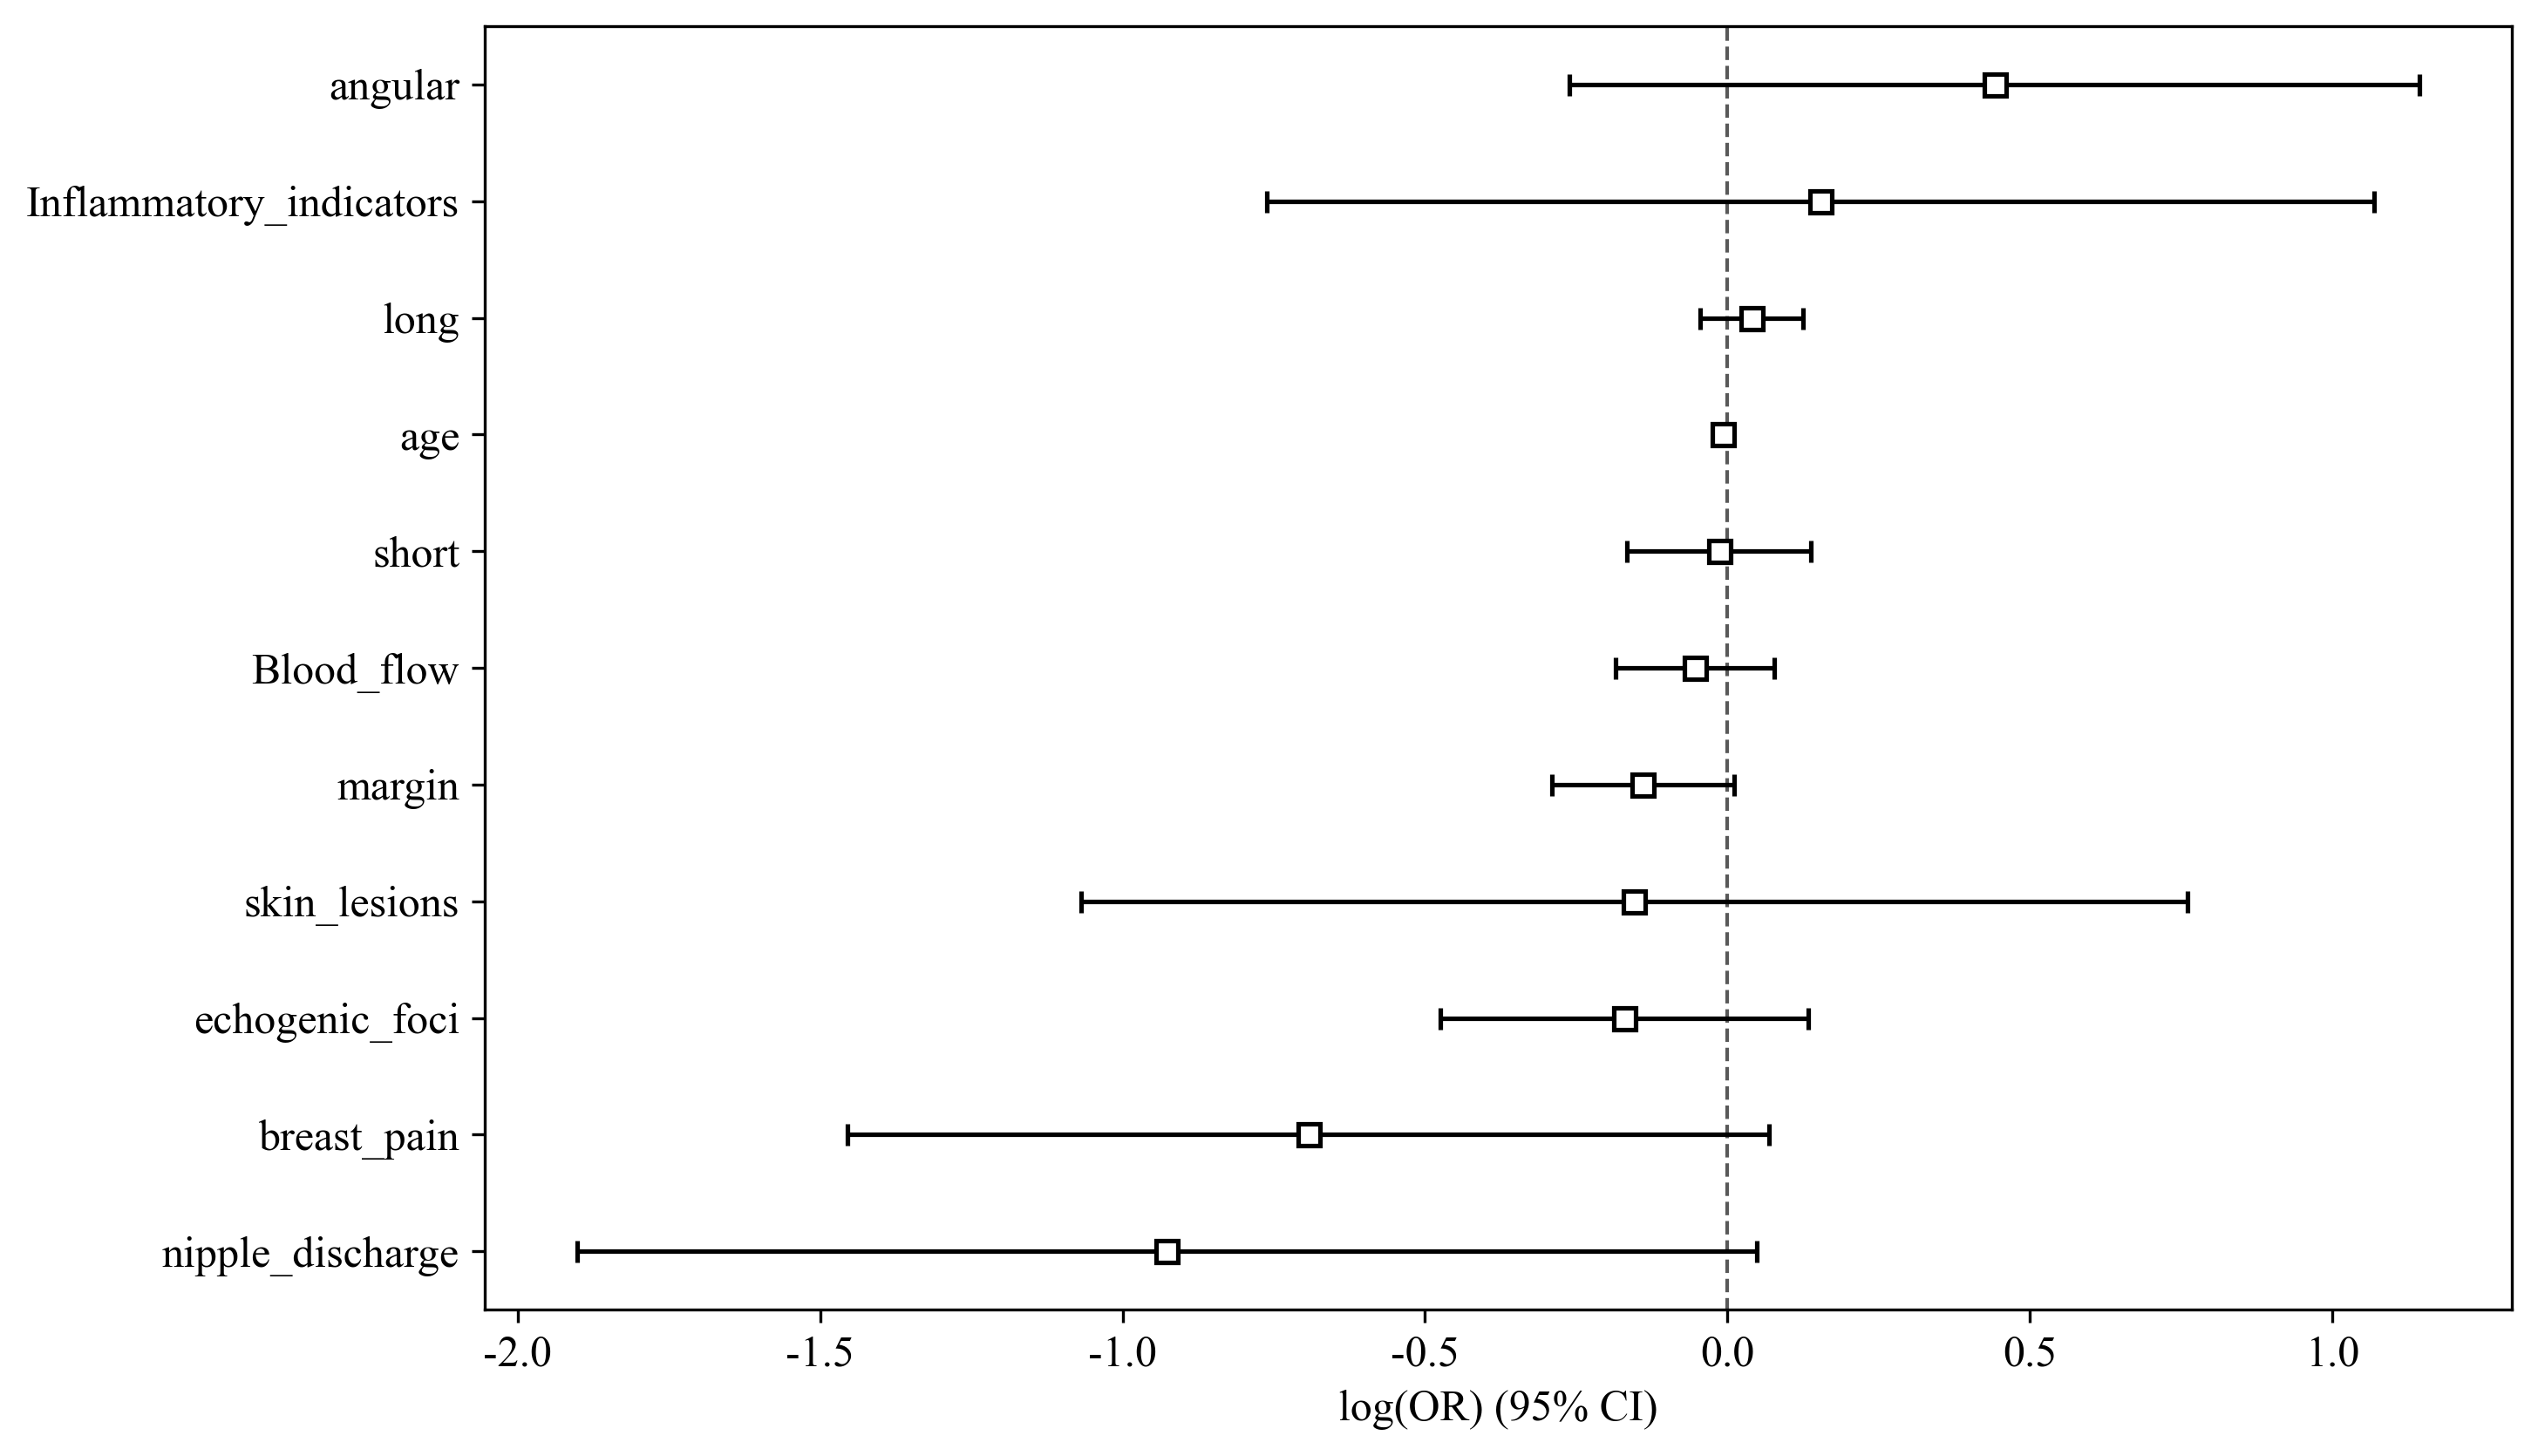

Optimization terminated successfully.
         Current function value: 0.682196
         Iterations 4


,Log(OR),lower 95%CI,upper 95%CI,OR,OR lower 95%CI,OR upper 95%CI,p_value
feature_name,,,,,,,
age,-0.007,-0.013,-0.001,0.993,0.987,0.999,0.043


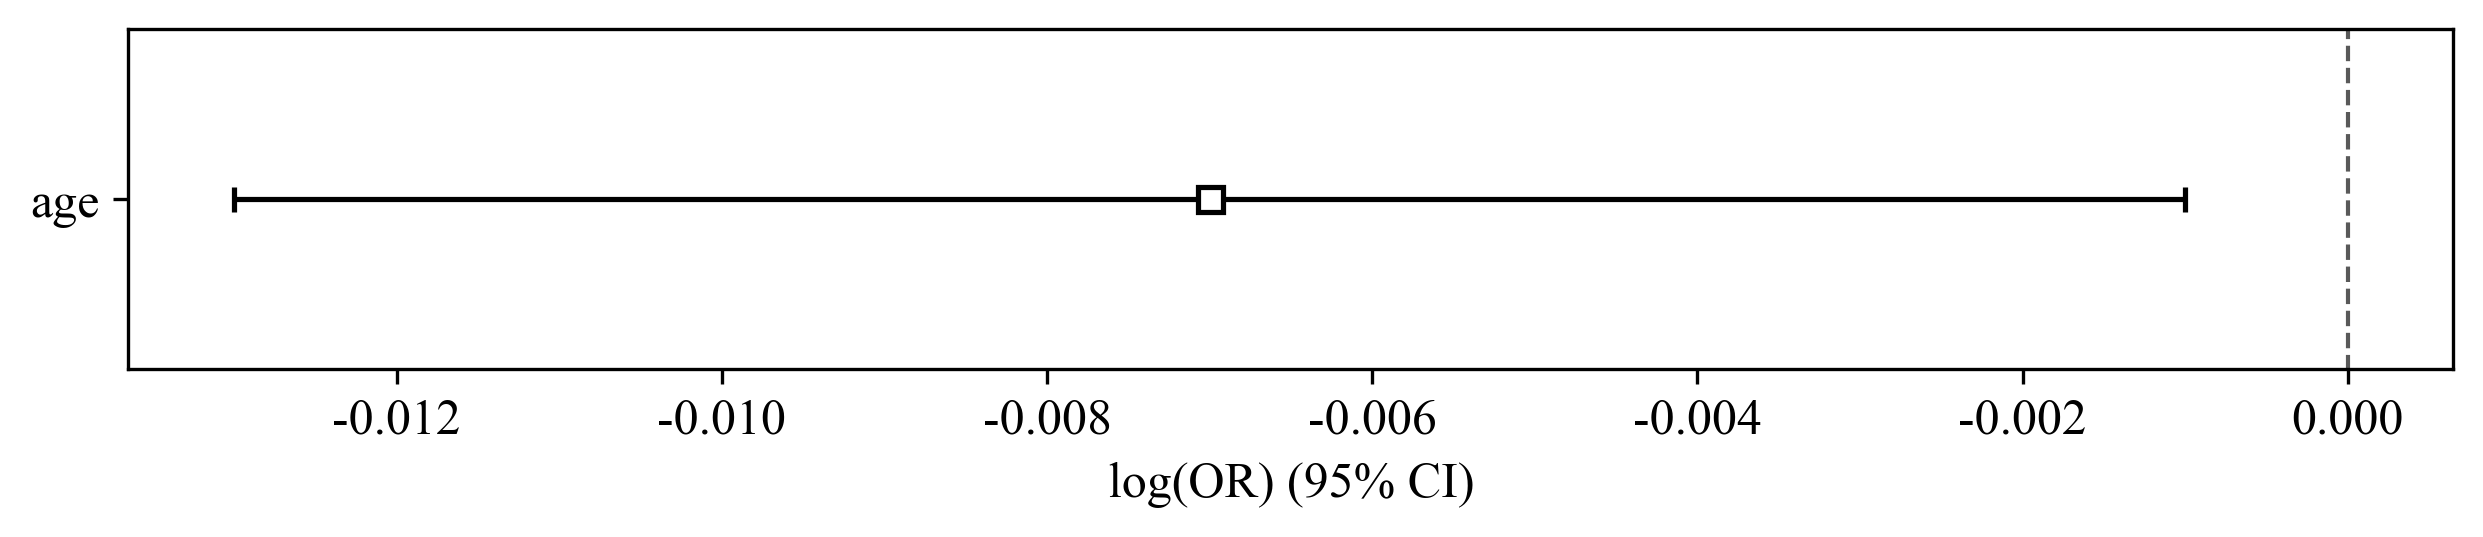

In [10]:
from onekey_algo.custom.components.comp1 import uni_multi_variable_analysis                        

uni_multi_variable_analysis(data[data['group'] == 'train'], stats_columns, save_dir='img', p_value4multi=p_value, algo='logit')